In [1]:
import numpy as np
X0 = np.sort(np.random.randint(-50,50,size=(50,1)), axis=0)
Y0 = np.random.randint(-50,50,size=(50,1))
R = Y0

In [2]:
def gauss01Kernel(x):
    m = 0
    s = 1
    return np.exp(-np.pow((x-m), 2)/np.pow(s,2))

def dGauss01Kernel(x):
    m = 0
    s = 1
    return -2 * (x - m)/np.pow(s, 2) * gauss01Kernel(x)

def Activate(X):
    return gauss01Kernel(X)

def pActivate(X):
    return dGauss01Kernel(X)

In [3]:
D0 = 50 # 输入层 1 个x样本
D1 = 50
D2 = D0 # 输出层

W1 = np.random.randn(D1, D0)
W2 = np.random.randn(D2, D1)
B1 = np.random.randn(D1, 1)
B2 = np.random.randn(D2, 1)

eta = 1e-3

def evaluation(X0):
    AX1 = W1 @ X0 + B1
    X1 = Activate(AX1)
    AX2 = W2 @ X1 + B2
    X2 = AX2
    Y = X2
    return Y

def train(nIters):
    global W1,W2,W3,B1,B2,B3
    iters = []
    losses = []
    for it in range(nIters):
        AX1 = W1 @ X0 + B1
        X1 = Activate(AX1)
        AX2 = W2 @ X1 + B2
        X2 = AX2
        Y = X2
        E = Y - R
        L = 0.5 * E.T @ E

        d_L_d_X2 = E
        delta2 = d_L_d_X2
        d_L_d_W2 = delta2 @ X1.T
        d_L_d_B2 = delta2

        delta1 = W2.T @ delta2 * pActivate(AX1)
        d_L_d_W1 = delta1 @ X0.T
        d_L_d_B1 = delta1

        W2 = W2 - eta * d_L_d_W2
        B2 = B2 - eta * d_L_d_B2
        W1 = W1 - eta * d_L_d_W1
        B1 = B1 - eta * d_L_d_B1

        iters.append(it)
        losses.append(np.sum(L))

        print(f"\rIter: {it}, Loss: {np.sum(L)}", end="")
    return iters, losses

iters, losses = train(10000)

Iter: 9999, Loss: 3.762915466015822e-055

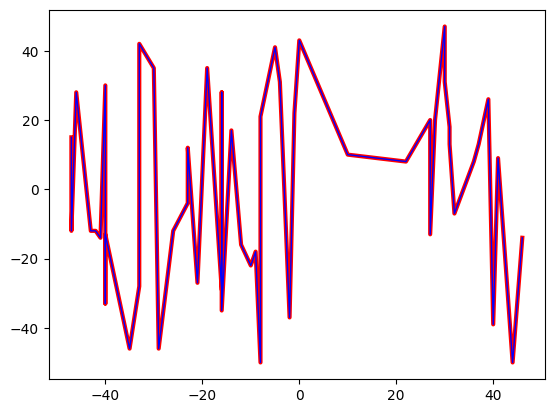

In [4]:
import matplotlib.pyplot as plt
xs = X0
rs = R
ys = evaluation(X0)

plt.plot(xs, ys, color='r', lw=3)
plt.plot(xs, rs, color='b', lw=1)
